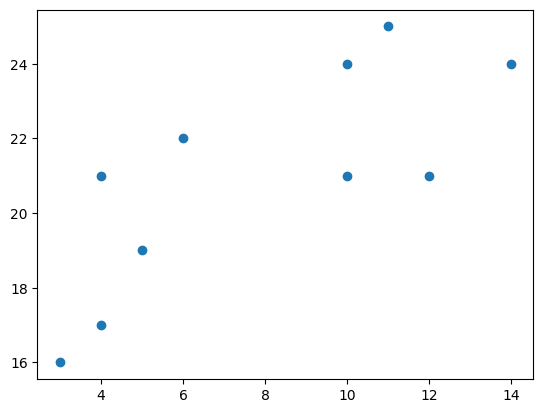

In [1]:
import matplotlib.pyplot as plt

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

plt.scatter(x, y)
plt.show() 

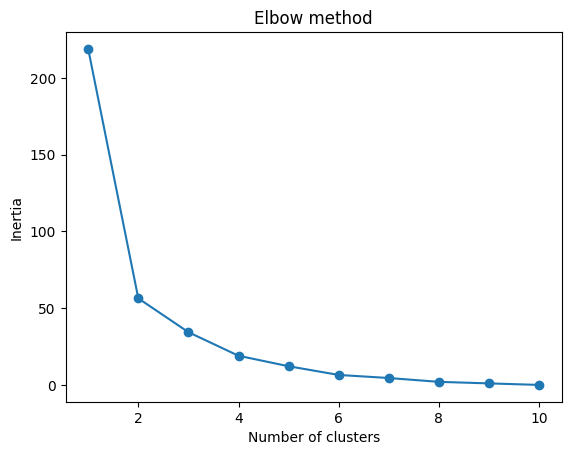

In [2]:
from sklearn.cluster import KMeans

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show() 

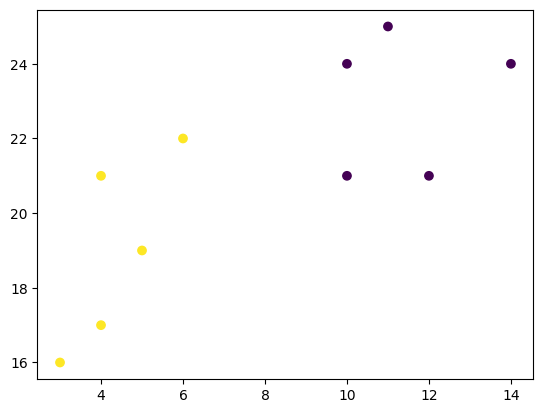

In [3]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show() 

## Simple Project Example

Generating sample data...
Generated 300 data points
Visualizing raw data...


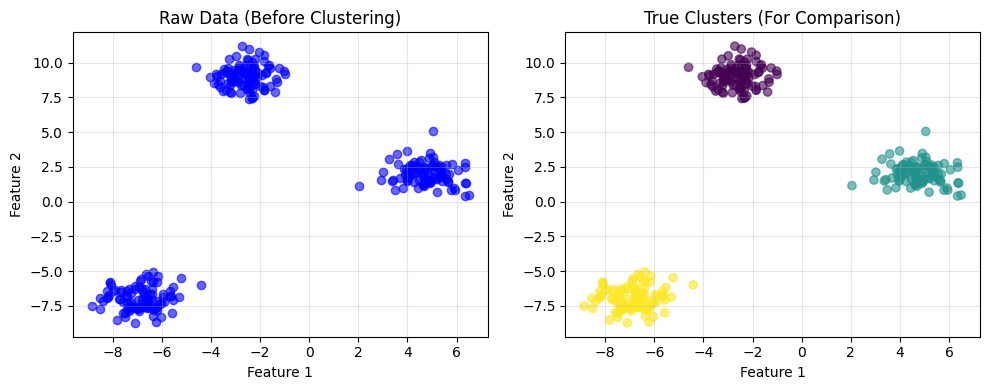

Applying K-means clustering...
Visualizing results...


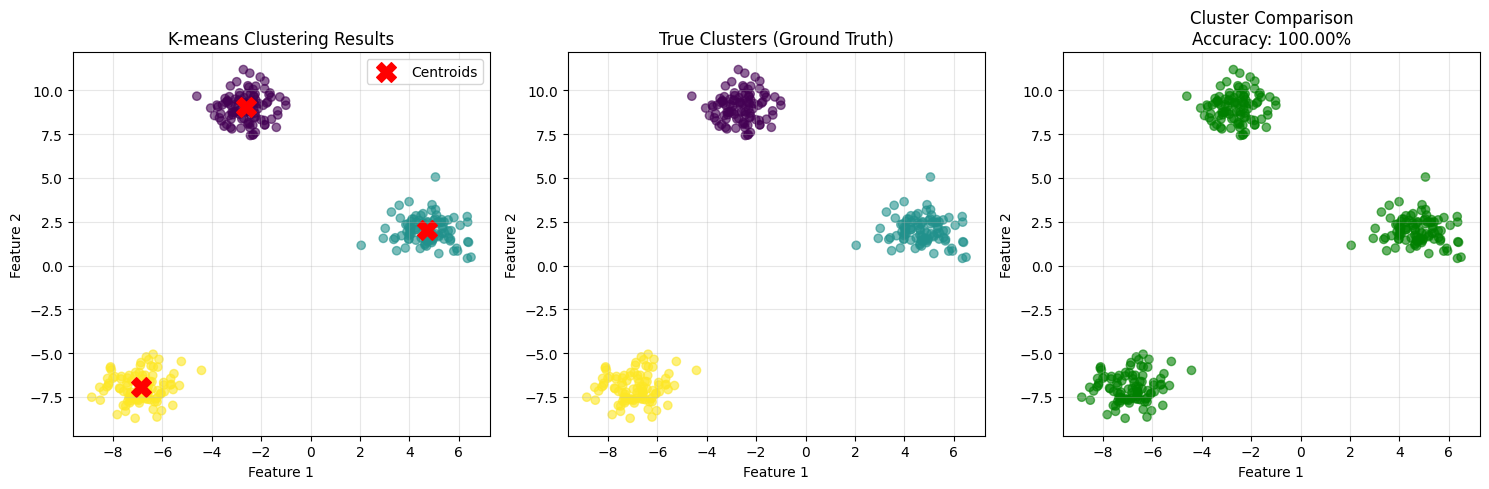


CLUSTER ANALYSIS
Cluster 0:
  Number of points: 100
  Mean Feature 1: -2.61
  Mean Feature 2: 9.04
  Standard deviation: 5.87

Cluster 1:
  Number of points: 100
  Mean Feature 1: 4.73
  Mean Feature 2: 2.00
  Standard deviation: 1.57

Cluster 2:
  Number of points: 100
  Mean Feature 1: -6.88
  Mean Feature 2: -6.96
  Standard deviation: 0.80

Running elbow method to find optimal number of clusters...


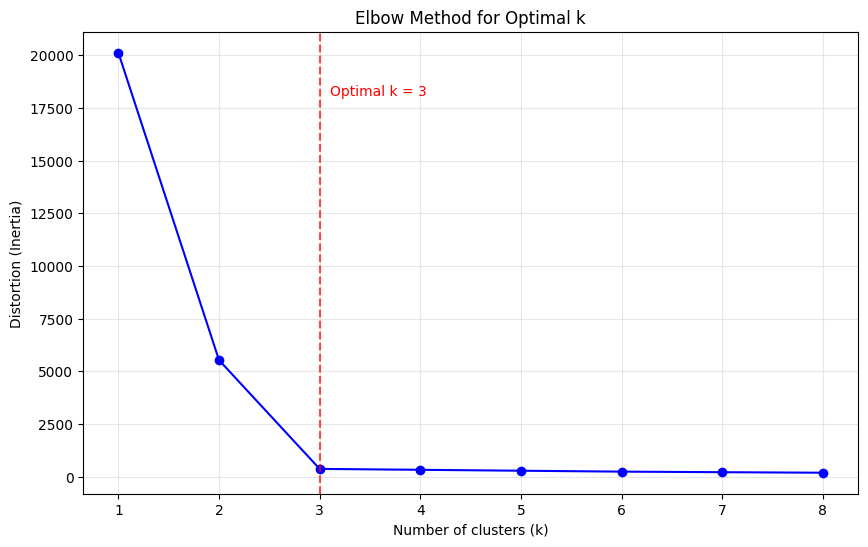


Sample data points and their clusters:
Point 203: Features = [4.16838703 2.65285136], Predicted Cluster = 1, True Cluster = 1
Point 266: Features = [-6.78339069 -6.46855853], Predicted Cluster = 2, True Cluster = 2
Point 152: Features = [4.86467233 1.47501007], Predicted Cluster = 1, True Cluster = 1
Point 9: Features = [-3.46224042  9.53952902], Predicted Cluster = 0, True Cluster = 0
Point 233: Features = [-7.826234   -8.51149534], Predicted Cluster = 2, True Cluster = 2
Point 226: Features = [-7.2350618 -6.5782692], Predicted Cluster = 2, True Cluster = 2
Point 196: Features = [4.62466587 1.17114619], Predicted Cluster = 1, True Cluster = 1
Point 109: Features = [-7.99848125 -6.4297342 ], Predicted Cluster = 2, True Cluster = 2
Point 5: Features = [5.32600653 1.84521886], Predicted Cluster = 1, True Cluster = 1
Point 175: Features = [4.65948698 2.37156832], Predicted Cluster = 1, True Cluster = 1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

class SimpleKMeansProject:
    def __init__(self):
        self.data = None
        self.labels = None
        self.kmeans = None
        
    def generate_sample_data(self):
        """Generate sample 2D data with 3 clusters"""
        # Create 300 sample points with 3 centers
        self.data, self.labels = make_blobs(
            n_samples=300, 
            centers=3, 
            cluster_std=0.8, 
            random_state=42
        )
        print(f"Generated {len(self.data)} data points")
        return self.data
    
    def visualize_raw_data(self):
        """Plot the raw data before clustering"""
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.scatter(self.data[:, 0], self.data[:, 1], c='blue', alpha=0.6)
        plt.title('Raw Data (Before Clustering)')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.scatter(self.data[:, 0], self.data[:, 1], c=self.labels, 
                   cmap='viridis', alpha=0.6)
        plt.title('True Clusters (For Comparison)')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def apply_kmeans(self, n_clusters=3):
        """Apply K-means clustering"""
        self.kmeans = KMeans(
            n_clusters=n_clusters,
            init='random',
            n_init=10,
            max_iter=300,
            random_state=42
        )
        
        # Fit the model and predict clusters
        predicted_labels = self.kmeans.fit_predict(self.data)
        
        return predicted_labels, self.kmeans.cluster_centers_
    
    def visualize_results(self, predicted_labels, centers):
        """Visualize the clustering results"""
        plt.figure(figsize=(15, 5))
        
        # Plot 1: K-means clusters
        plt.subplot(1, 3, 1)
        scatter = plt.scatter(self.data[:, 0], self.data[:, 1], 
                            c=predicted_labels, cmap='viridis', alpha=0.6)
        plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, 
                   label='Centroids')
        plt.title('K-means Clustering Results')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 2: True clusters for comparison
        plt.subplot(1, 3, 2)
        plt.scatter(self.data[:, 0], self.data[:, 1], c=self.labels, 
                   cmap='viridis', alpha=0.6)
        plt.title('True Clusters (Ground Truth)')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.grid(True, alpha=0.3)
        
        # Plot 3: Cluster comparison
        plt.subplot(1, 3, 3)
        correct = np.sum(predicted_labels == self.labels)
        accuracy = correct / len(self.labels)
        
        colors = ['green' if p == t else 'red' 
                 for p, t in zip(predicted_labels, self.labels)]
        
        plt.scatter(self.data[:, 0], self.data[:, 1], c=colors, alpha=0.6)
        plt.title(f'Cluster Comparison\nAccuracy: {accuracy:.2%}')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def analyze_clusters(self, predicted_labels):
        """Analyze and display cluster statistics"""
        print("\n" + "="*50)
        print("CLUSTER ANALYSIS")
        print("="*50)
        
        # Basic statistics
        unique, counts = np.unique(predicted_labels, return_counts=True)
        
        for cluster_id, count in zip(unique, counts):
            cluster_data = self.data[predicted_labels == cluster_id]
            print(f"Cluster {cluster_id}:")
            print(f"  Number of points: {count}")
            print(f"  Mean Feature 1: {cluster_data[:, 0].mean():.2f}")
            print(f"  Mean Feature 2: {cluster_data[:, 1].mean():.2f}")
            print(f"  Standard deviation: {np.std(cluster_data):.2f}")
            print()
    
    def elbow_method(self, max_clusters=10):
        """Use elbow method to find optimal number of clusters"""
        distortions = []
        K = range(1, max_clusters + 1)
        
        for k in K:
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(self.data)
            distortions.append(kmeans.inertia_)
        
        # Plot elbow curve
        plt.figure(figsize=(10, 6))
        plt.plot(K, distortions, 'bo-')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Distortion (Inertia)')
        plt.title('Elbow Method for Optimal k')
        plt.grid(True, alpha=0.3)
        
        # Highlight the "elbow"
        elbow_k = 3  # We know this from our data generation
        plt.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.7)
        plt.text(elbow_k + 0.1, max(distortions) * 0.9, 
                f'Optimal k = {elbow_k}', color='red')
        
        plt.show()
        
        return distortions

# Main execution
if __name__ == "__main__":
    # Create project instance
    project = SimpleKMeansProject()
    
    # Step 1: Generate sample data
    print("Generating sample data...")
    data = project.generate_sample_data()
    
    # Step 2: Visualize raw data
    print("Visualizing raw data...")
    project.visualize_raw_data()
    
    # Step 3: Apply K-means clustering
    print("Applying K-means clustering...")
    predicted_labels, centers = project.apply_kmeans(n_clusters=3)
    
    # Step 4: Visualize results
    print("Visualizing results...")
    project.visualize_results(predicted_labels, centers)
    
    # Step 5: Analyze clusters
    project.analyze_clusters(predicted_labels)
    
    # Step 6: Elbow method for optimal k
    print("Running elbow method to find optimal number of clusters...")
    distortions = project.elbow_method(max_clusters=8)
    
    # Additional: Show some sample points and their clusters
    print("\nSample data points and their clusters:")
    sample_indices = np.random.choice(len(data), 10, replace=False)
    for i in sample_indices:
        print(f"Point {i}: Features = {data[i]}, "
              f"Predicted Cluster = {predicted_labels[i]}, "
              f"True Cluster = {project.labels[i]}")